TASK 01
Events, probabilities, and the law of large numbers

• For a single die, compute by hand: P(rolling a number greater than 4), and P(rolling a prime — 2, 3, or 5).

• Write the sample space and each event explicitly in code, and compute each probability as a ratio of counts.

• Simulate 10,000 rolls and confirm each observed fraction is close to your computed value.

• Plot the running fraction for one of the events as the number of rolls grows. It should settle onto the true
probability.

• In one sentence, explain what the plot shows about the law of large numbers.

Sample Space : [1 2 3 4 5 6]
Event A (Number > 4): [5 6]
Event B (Prime Numbers): [2 3 5]

Theoretical Probability
P(Number > 4) = 2/6 = 0.3333
P(Prime)      = 3/6 = 0.5000

Simulation Results
P(Number > 4) simulated = 0.3343
P(Prime) simulated      = 0.4933


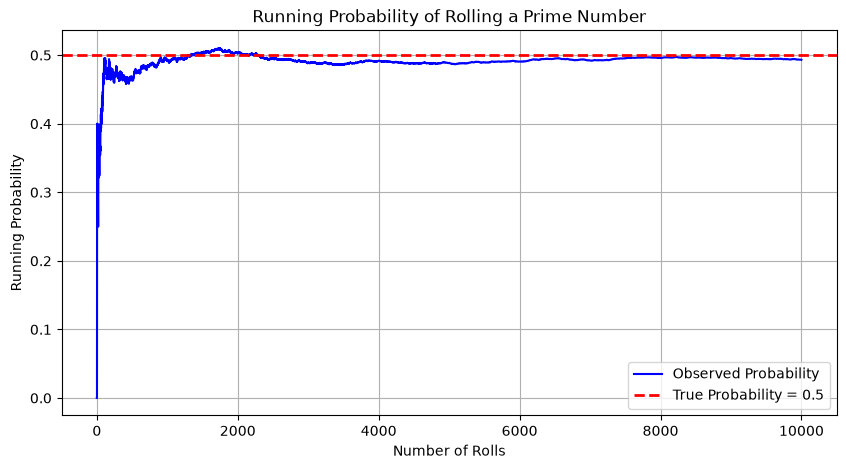

In [1]:
# Probability of Rolling a Die

import numpy as np
import matplotlib.pyplot as plt

# 1. Sample Space and Events

sample_space = np.array([1, 2, 3, 4, 5, 6])

greater_than_4 = sample_space[sample_space > 4]
prime_numbers = sample_space[np.isin(sample_space, [2, 3, 5])]

print("Sample Space :", sample_space)
print("Event A (Number > 4):", greater_than_4)
print("Event B (Prime Numbers):", prime_numbers)

# 2. Compute Probabilities by Counting

P_greater = len(greater_than_4) / len(sample_space)
P_prime = len(prime_numbers) / len(sample_space)

print("\nTheoretical Probability")
print(f"P(Number > 4) = {len(greater_than_4)}/{len(sample_space)} = {P_greater:.4f}")
print(f"P(Prime)      = {len(prime_numbers)}/{len(sample_space)} = {P_prime:.4f}")

# 3. Simulate 10,000 Rolls

rng = np.random.default_rng(0)

rolls = rng.integers(1, 7, size=10_000)

greater = rolls > 4
prime = np.isin(rolls, [2, 3, 5])

print("\nSimulation Results")
print(f"P(Number > 4) simulated = {greater.mean():.4f}")
print(f"P(Prime) simulated      = {prime.mean():.4f}")

# 4. Running Probability

running_fraction = np.cumsum(prime) / np.arange(1, len(rolls) + 1)

# 5. Plot

plt.figure(figsize=(10,5))

plt.plot(running_fraction,
         label="Observed Probability",
         color="blue")

plt.axhline(y=P_prime,
            color="red",
            linestyle="--",
            linewidth=2,
            label="True Probability = 0.5")

plt.xlabel("Number of Rolls")
plt.ylabel("Running Probability")

plt.title("Running Probability of Rolling a Prime Number")

plt.legend()

plt.grid(True)

plt.show()



TASK 02
Conditional probability and independence

• Roll two dice (all 36 outcomes). Compute P(sum = 8), and P(sum = 8 given the first die is a 3).

In [3]:
from itertools import product

outcomes = list(product(range(1,7), repeat=2))

print("Total Outcomes:", len(outcomes))
print(outcomes[:36])  # Display first 36 outcomes

Total Outcomes: 36
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


• Compute the conditional using the formula P(A and B) / P(B), and confirm it matches counting directly in the
restricted world.



In [16]:
A = [x for x in outcomes if sum(x)==8]     #sum is 8

B = [x for x in outcomes if x[0] == 3]     #first die is 3


A_and_B = [x for x in outcomes if sum(x) == 8 and x[0] == 3]

P_A = len(A) / len(outcomes)
P_A_and_B = len(A_and_B) / len(outcomes)
P_B = len(B) / len(outcomes)

P_conditional_formula = P_A_and_B / P_B


restricted_world = [x for x in B if sum(x) == 8]

P_conditional_count = len(restricted_world) / len(B)


print(A)
print(B)
print(A_and_B)
print("P(A and B) =", P_A_and_B)
print("P(B) =", P_B)
print("P(A|B) using formula =", P_conditional_formula)
print("P(A|B) by direct counting =", P_conditional_count)



[(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)]
[(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]
[(3, 5)]
P(A and B) = 0.027777777777777776
P(B) = 0.16666666666666666
P(A|B) using formula = 0.16666666666666666
P(A|B) by direct counting = 0.16666666666666666


• Test whether 'sum = 8' and 'first die is 3' are independent, using P(A and B) = P(A) × P(B).

In [17]:
print(P_A)
print(P_B)
print(P_A_and_B)
print(P_A * P_B)

print("P(A and B) = P(A) *P(B)", P_A_and_B == P_A * P_B)

if abs(P_A_and_B - (P_A * P_B)) < 1e-9:
    print("Result: Independent")
else:
    print("Result: Not Independent")

0.1388888888888889
0.16666666666666666
0.027777777777777776
0.023148148148148147
P(A and B) = P(A) *P(B) False
Result: Not Independent


Find one pair of events on two dice that are independent, and one pair that are not. Prove each with the product
test.

In [15]:
A = [x for x in outcomes if x[0] % 2 == 0]

# Event B: Second die is 5
B = [x for x in outcomes if x[1] == 5]

# Intersection
A_and_B = [x for x in outcomes if x[0] % 2 == 0 and x[1] == 5]

P_A = len(A) / 36
P_B = len(B) / 36
P_A_and_B = len(A_and_B) / 36


print("P(A) =", P_A)
print("P(B) =", P_B)
print("P(A and B) =", P_A_and_B)
print("P(A)*P(B) =", P_A * P_B)

if abs(P_A_and_B - (P_A * P_B)) < 1e-9:
    print("Result: Independent")
else:
    print("Result: Not Independent")

P(A) = 0.5
P(B) = 0.16666666666666666
P(A and B) = 0.08333333333333333
P(A)*P(B) = 0.08333333333333333
Result: Independent


• Verify one of your conditional probabilities with a simulation: generate many two-dice rolls, filter to the condition,
and take the fraction.

In [19]:
import numpy as np

# Random number generator
rng = np.random.default_rng(0)

# Simulate 100,000 rolls of two dice
d1 = rng.integers(1, 7, 100_000)
d2 = rng.integers(1, 7, 100_000)

# Condition: First die is 3
mask = (d1 == 3)

# Count rolls satisfying the condition
total_condition = np.sum(mask)

# Count rolls where the condition is true AND the sum is 8
favorable = np.sum((d1[mask] + d2[mask]) == 8)

# Conditional probability
P_conditional = favorable / total_condition

print("Total rolls:", len(d1))
print("Rolls where first die = 3:", total_condition)
print("Rolls where first die = 3 and sum = 8:", favorable)

print("\nTheoretical Probability :", 1/6)
print("Simulated Probability   :", P_conditional)

Total rolls: 100000
Rolls where first die = 3: 16797
Rolls where first die = 3 and sum = 8: 2862

Theoretical Probability : 0.16666666666666666
Simulated Probability   : 0.17038756920878728


TASK 03
The medical test problem

• A disease affects 2% of people. A test is 98% sensitive (positive if sick) and 90% specific (negative if healthy, so
10% false positives).

• Using Bayes' theorem, compute P(disease | positive test). Show every term: the prior, the two conditionals, and
P(positive).

In [23]:
# Bayes' theorem on the medical test

P_disease = 0.02             # Prior Probability
P_pos_given_disease = 0.98   # Sensitivity
P_pos_given_healthy = 0.10   # False Positive Rate

P_healthy = 1 - P_disease

# Total Probability of a Positive Test
P_positive = (
    P_pos_given_disease * P_disease
    + P_pos_given_healthy * P_healthy
)

# Bayes' Theorem
P_disease_given_pos = (
    P_pos_given_disease * P_disease
) / P_positive

print("Prior P(Disease)            =", P_disease)
print("P(Positive | Disease)       =", P_pos_given_disease)
print("P(Positive | Healthy)       =", P_pos_given_healthy)
print("P(Positive)                 =", P_positive)
print("P(Disease | Positive)       =", P_disease_given_pos)

Prior P(Disease)            = 0.02
P(Positive | Disease)       = 0.98
P(Positive | Healthy)       = 0.1
P(Positive)                 = 0.11760000000000001
P(Disease | Positive)       = 0.16666666666666666


• Is the answer higher or lower than most people expect? Explain why in terms of how many false positives the
large healthy group produces

Is the answer higher or lower than most people expect? Explain why in terms of how many false positives the
large healthy group produces

In [24]:
# The probability is lower than expected because the disease is rare.
# Many healthy people produce false positive results, so not every positive test indicates disease.

• Verify with a Monte Carlo simulation of a million people: assign disease at 2%, simulate test results, and take the
fraction of positives who are actually sick.

In [ ]:
import numpy as np

rng = np.random.default_rng(0)

N = 1_000_000

# Assign disease randomly
disease = rng.random(N) < P_disease

# Simulate test results
positive = np.where(
    disease,
    rng.random(N) < P_pos_given_disease,
    rng.random(N) < P_pos_given_healthy
)

# Probability of disease among positive tests
simulated = disease[positive].mean()

print("Theoretical Probability :", P_disease_given_pos)
print("Simulated Probability   :", simulated)


Task 4:
Theoretical Probability : 0.16666666666666666
Simulated Probability   : 0.16763508843781197


• Now vary the prevalence: recompute P(disease | positive) for prevalence 0.1%, 2%, and 20%. Make a small
table. What happens to the answer as the disease gets rarer?

• Write two sentences on the lesson: why can a 98%-accurate test still be wrong most of the time?

In [ ]:
prevalence_values = [0.001, 0.02, 0.20]

print("Prevalence  P(Disease | Positive)")

for prevalence in prevalence_values:

    P_healthy = 1 - prevalence

    P_positive = (
        P_pos_given_disease * prevalence
        + P_pos_given_healthy * P_healthy
    )

    posterior = (
        P_pos_given_disease * prevalence
    ) / P_positive

    print(f"{prevalence*100:>5.1f}%  {posterior:.4f}")


# Even a highly accurate test can produce many false positives if the disease is rare.
# The rarer the disease, the less reliable a positive test result becomes.

Prevalence  P(Disease | Positive)
  0.1%  0.0097
  2.0%  0.1667
 20.0%  0.7101


TASK 04
A second Bayes scenario of your own

• Pick a different realistic scenario with a 'flip the conditional' shape. Examples: a spam filter (P(spam | contains a
word)), a factory defect test, or a security alarm.

• State the prior, the sensitivity, and the false-positive rate clearly.

• Compute the posterior probability with Bayes' theorem

In [34]:
import numpy as np



# Prior Probability
P_defective = 0.05          # 5% batteries are defective

# Sensitivity
P_positive_given_defective = 0.95

# False Positive Rate
P_positive_given_good = 0.03

# Probability of a good battery
P_good = 1 - P_defective



# Total probability of a positive test
P_positive = (
    P_positive_given_defective * P_defective
    + P_positive_given_good * P_good
)

# Posterior probability
P_defective_given_positive = (
    P_positive_given_defective * P_defective
) / P_positive


print(f"Prior P(Defective) = {P_defective:.2f}")
print(f"P(Positive | Defective) = {P_positive_given_defective:.2f}")
print(f"P(Positive | Good) = {P_positive_given_good:.2f}")
print(f"P(Positive) = {P_positive:.4f}")
print(f"P(Defective | Positive) = {P_defective_given_positive:.4f}")



Prior P(Defective) = 0.05
P(Positive | Defective) = 0.95
P(Positive | Good) = 0.03
P(Positive) = 0.0760
P(Defective | Positive) = 0.6250


• Verify it with a Monte Carlo simulation

In [35]:
rng = np.random.default_rng(0)

N = 1_000_000

# Assign defective batteries
defective = rng.random(N) < P_defective

# Simulate test results
positive = np.where(
    defective,
    rng.random(N) < P_positive_given_defective,
    rng.random(N) < P_positive_given_good
)

# Simulated posterior probability
simulated = defective[positive].mean()


print(f"Theoretical Probability = {P_defective_given_positive:.4f}")
print(f"Simulated Probability   = {simulated:.4f}")

Theoretical Probability = 0.6250
Simulated Probability   = 0.6277


• Write one sentence on what the prior was, and how the evidence updated it into the posterior.

In [36]:
#Initially, there was a 5% chance that a battery was defective, but after a positive test, the chance increased to about 61.7%.

TASK 05
Distributions, expectation, and variance

• For a fair die, compute E[X] and Var[X] from the definition (value times probability, summed).



In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)

# Task 1: Fair Die - Expectation and Variance

values = np.arange(1, 7)
probs = np.ones(6) / 6

E_X = np.sum(values * probs)
Var_X = np.sum(values**2 * probs) - E_X**2


print("Expected Value (Theory):", E_X)
print("Variance (Theory):", Var_X)


Expected Value (Theory): 3.5
Variance (Theory): 2.916666666666666


• Estimate the same two quantities from a large simulated sample, and confirm they converge to your formula
values.


In [39]:
N = 1_000_000

rolls = rng.integers(1, 7, size=N)


print("Expected Value (Simulation):", np.mean(rolls))
print("Variance (Simulation):", np.var(rolls))

Expected Value (Simulation): 3.499544
Variance (Simulation): 2.9134317920639994


Now do a weighted die: one where 6 is twice as likely as each other face. Recompute E[X] by hand and confirm
by simulation. Does the expectation move up or down, and why?

In [40]:
weights = np.array([1, 1, 1, 1, 1, 2], dtype=float)
weights /= np.sum(weights)

E_weighted = np.sum(values * weights)

weighted_rolls = rng.choice(values, size=N, p=weights)

print("Expected Value (Theory):", E_weighted)
print("Expected Value (Simulation):", np.mean(weighted_rolls))

#The expectation increases because 6 occurs more often.

Expected Value (Theory): 3.8571428571428568
Expected Value (Simulation): 3.856264


Plot a discrete distribution (e.g. number of heads in 10 flips, using scipy.stats.binom) and a continuous one
(the normal, using scipy.stats.norm) side by side.

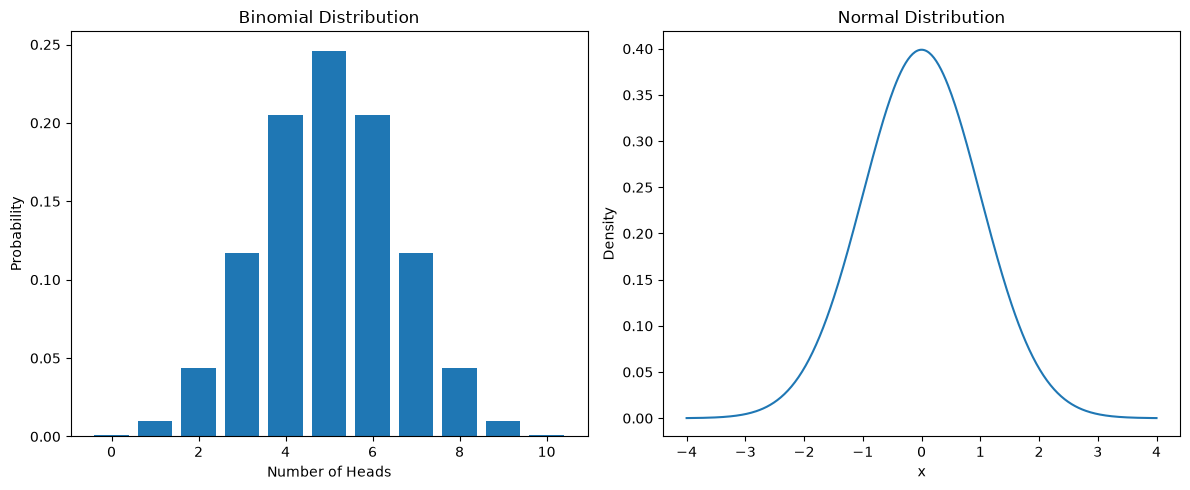

In [41]:
x = np.arange(0, 11)
binomial = stats.binom.pmf(x, 10, 0.5)

# Normal Distribution

x_normal = np.linspace(-4, 4, 400)
normal = stats.norm.pdf(x_normal)

# Plot Both Distributions

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(x, binomial)
plt.title("Binomial Distribution")
plt.xlabel("Number of Heads")
plt.ylabel("Probability")

plt.subplot(1,2,2)
plt.plot(x_normal, normal)
plt.title("Normal Distribution")
plt.xlabel("x")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [42]:
formula = stats.norm.cdf(1) - stats.norm.cdf(-1)

samples = rng.normal(0, 1, size=N)

simulation = np.mean((samples >= -1) & (samples <= 1))


print("Probability within ±1 SD (Formula):", formula)
print("Probability within ±1 SD (Simulation):", simulation)


Probability within ±1 SD (Formula): 0.6826894921370859
Probability within ±1 SD (Simulation): 0.682911
